In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.arange(1 , 20, 1)
y = 1 + x ** 2

print(x.shape)
print(y.shape)
print(x)
print(y)

(19,)
(19,)
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[  2   5  10  17  26  37  50  65  82 101 122 145 170 197 226 257 290 325
 362]


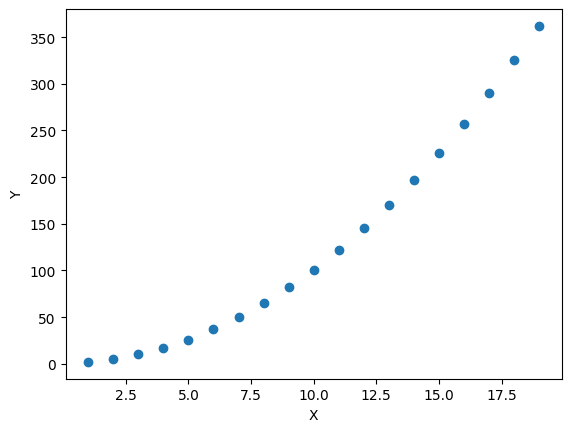

In [3]:
plt.scatter(x,y)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

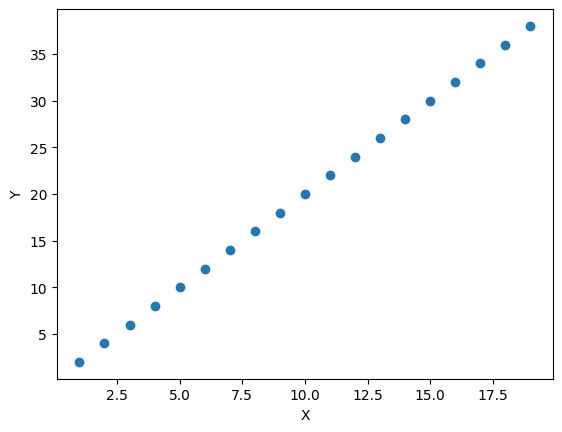

In [4]:
y1 = 2 * x
plt.scatter(x,y1)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [5]:
w = 0.2
b = 1

In [6]:
pred = w * x + b
print(pred)

[1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4 3.6 3.8 4.  4.2 4.4 4.6
 4.8]


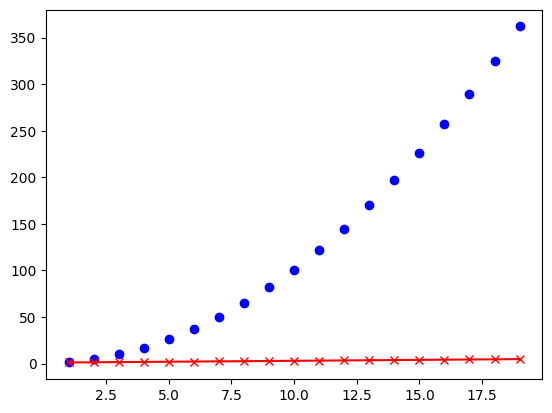

In [7]:
plt.scatter(x, y, c='b')
plt.plot(x,pred, marker = "x" , c='r')
plt.show()

In [8]:
x2 = x ** 2
print(x2)

[  1   4   9  16  25  36  49  64  81 100 121 144 169 196 225 256 289 324
 361]


In [9]:
x_train = np.column_stack((x, x2))

In [10]:
print(x_train.shape)
print(x_train.ndim)
print(x_train)

(19, 2)
2
[[  1   1]
 [  2   4]
 [  3   9]
 [  4  16]
 [  5  25]
 [  6  36]
 [  7  49]
 [  8  64]
 [  9  81]
 [ 10 100]
 [ 11 121]
 [ 12 144]
 [ 13 169]
 [ 14 196]
 [ 15 225]
 [ 16 256]
 [ 17 289]
 [ 18 324]
 [ 19 361]]


In [11]:
w = np.array([0.5 , 1.0])
b = 1

In [12]:
print(x_train[:2])

[[1 1]
 [2 4]]


In [13]:
pred = np.dot(w , x_train[2]) + b
print(pred)

11.5


In [14]:
m = x_train.shape[0]
pred = np.zeros(m)
print(m)
pred = np.zeros(m)
for i in range(m):
  f_wb = np.dot(w , x_train[i]) + b
  pred[i] = f_wb
print(pred)

19
[  2.5   6.   11.5  19.   28.5  40.   53.5  69.   86.5 106.  127.5 151.
 176.5 204.  233.5 265.  298.5 334.  371.5]


In [15]:
def compute_cost(x, y, w, b):
  cost = 0
  m = x.shape[0]
  f_wb = np.zeros(m)
  for i in range(m):
    f_wb_i = np.dot(w , x[i]) + b
    j_wb_i = (f_wb_i - y[i]) ** 2
    cost = cost + j_wb_i
  cost = cost / (2 * m)
  return cost

In [16]:
prediction_cost = compute_cost(x_train, y , w , b)
print(prediction_cost)

16.25


In [17]:
def compute_gradient(x,w,b):
  dj_dw = 0
  dj_db = 0
  m = x.shape[0]

  for i in range(m):
    f_wb_i = np.dot(w , x[i]) + b
    error = f_wb_i - y[i]
    dj_dw_i = error * x[i]
    dj_db_i = error
    dj_dw = dj_dw + dj_dw_i
    dj_db = dj_db + dj_db_i
  dj_dw = dj_dw / m
  dj_db = dj_db / m
  return dj_dw , dj_db

In [18]:
dj_dw_f , dj_db_f = compute_gradient(x_train , w, b)
print(dj_dw_f)
print(dj_db_f)

[ 65. 950.]
5.0


In [19]:
import math

In [20]:
def gradient_descent(x,y,w,b,iters,alpha,cost_fun,gradient_fun):
  cost_history = []
  for iter in range(iters):

    dj_dw , dj_db = gradient_fun(x,w,b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    if iter <10000:
      cost_history.append(cost_fun(x,y,w,b))

    if iter % math.ceil(iters/10) == 0:
      print(f"Iteration: {iter} , Cost: {cost_history[-1]}")

  return cost_history, w , b

In [21]:
alpha = 1e-7
iters = 10000

In [22]:
overall_cost_history, w_final, b_final = gradient_descent(x_train, y, w, b, iters, alpha , compute_cost, compute_gradient)
print(overall_cost_history[:10])
print(f"Final w: {w_final}")
print(f"Final b: {b_final}")

Iteration: 0 , Cost: 16.15945981537889
Iteration: 1000 , Cost: 1.0414356423207682
Iteration: 2000 , Cost: 1.0006037686514404
Iteration: 3000 , Cost: 0.9988221408576733
Iteration: 4000 , Cost: 0.9971444623987423
Iteration: 5000 , Cost: 0.9954698641004386
Iteration: 6000 , Cost: 0.9937980800056124
Iteration: 7000 , Cost: 0.9921291047106187
Iteration: 8000 , Cost: 0.9904629334945907
Iteration: 9000 , Cost: 0.9887995616463163
[np.float64(16.15945981537889), np.float64(16.06945728989009), np.float64(15.9799892306669), np.float64(15.891052463803646), np.float64(15.802643834242375), np.float64(15.714760205661877), np.float64(15.627398460365228), np.float64(15.540555499170203), np.float64(15.454228241298827), np.float64(15.368413624268284)]
Final w: [0.4939505  0.96830418]
Final b: 0.9990380313921176


In [23]:
prediction = np.zeros(m)
for i in range(m):

  f_wb = np.dot(w_final , x_train[i]) + b_final
  prediction[i] = f_wb

print(prediction)

[  2.46129271   5.86015576  11.19562715  18.46770691  27.67639503
  38.8216915   51.90359633  66.92210953  83.87723107 102.76896098
 123.59729925 146.36224587 171.06380085 197.70196419 226.27673589
 256.78811595 289.23610436 323.62070114 359.94190627]


In [24]:
print(x_train.shape)
print(y1.shape)

(19, 2)
(19,)


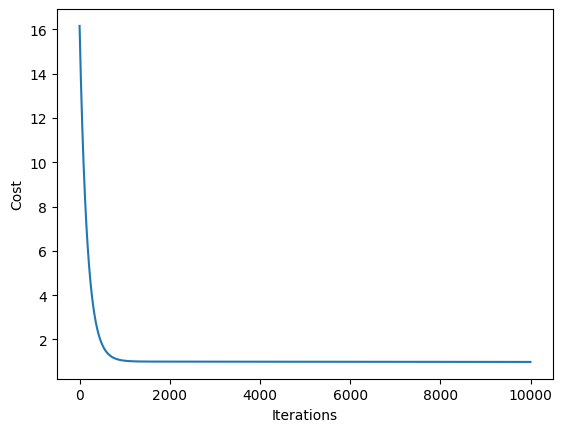

In [25]:
plt.plot(overall_cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

In [26]:
# Checking the modle prediction

print(f"Actual: {y[10]}")
print(f"Prediction: {prediction[10]}")

Actual: 122
Prediction: 123.59729924706467


In [27]:
# Checking the modle prediction

print(f"Actual: {y[15]}")
print(f"Prediction: {prediction[15]}")

Actual: 257
Prediction: 256.7881159489705


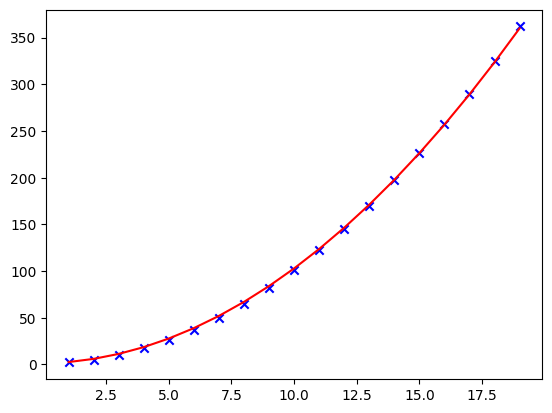

In [28]:
plt.scatter(x , y , label = "Actual Data" , c= 'b' , marker = 'x')
plt.plot(x, prediction , label = "Prediction" , c = 'r')
plt.show()

In [29]:
# Creating x3 feature
x3 = x ** 3
x_train = np.column_stack((x,x2,x3))
print(x_train)


[[   1    1    1]
 [   2    4    8]
 [   3    9   27]
 [   4   16   64]
 [   5   25  125]
 [   6   36  216]
 [   7   49  343]
 [   8   64  512]
 [   9   81  729]
 [  10  100 1000]
 [  11  121 1331]
 [  12  144 1728]
 [  13  169 2197]
 [  14  196 2744]
 [  15  225 3375]
 [  16  256 4096]
 [  17  289 4913]
 [  18  324 5832]
 [  19  361 6859]]


In [30]:
w_in = [0.1 ,0.2, 0.3]
b_in = 10

In [31]:
predictions = np.zeros(m)
for i in range(m):
  f_wb = np.dot(w_in , x_train[i]) + b_in
  predictions[i] = f_wb
print(predictions)


[  10.6   13.4   20.2   32.8   53.    82.6  123.4  177.2  245.8  331.
  434.6  558.4  704.2  873.8 1069.  1291.6 1543.4 1826.2 2141.8]


In [32]:
cost = compute_cost(x_train , y1 , w_in , b_in)
print(cost)

378966.4999999999


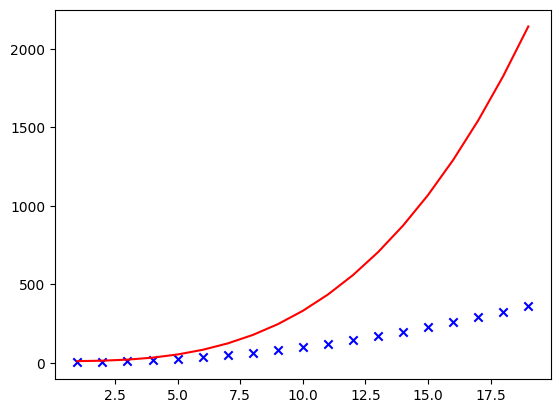

In [33]:
plt.scatter(x , y, label = "Actual" , marker = 'x' , c = 'b')
plt.plot(x, predictions, label = "Predicted" , c = 'r')
plt.show()


In [34]:
iters = 10000
alpha = 1e-7

In [35]:
cost_history, w_final , b_final = gradient_descent(x_train, y, w_in, b_in, iters, alpha, compute_cost, compute_gradient)

print(w_final)
print(b_final)
print(cost_history)

Iteration: 0 , Cost: 10024.568446829971
Iteration: 1000 , Cost: 143.2815325170678
Iteration: 2000 , Cost: 122.85353129336951
Iteration: 3000 , Cost: 105.56047412949377
Iteration: 4000 , Cost: 90.92120153997752
Iteration: 5000 , Cost: 78.52840368439182
Iteration: 6000 , Cost: 68.03728572625364
Iteration: 7000 , Cost: 59.15597286297421
Iteration: 8000 , Cost: 51.63738801748141
Iteration: 9000 , Cost: 45.272376163461644
[0.14751909 0.52810557 0.02559519]
10.004632741523793
[np.float64(10024.568446829971), np.float64(541.0908433760302), np.float64(181.5283507148778), np.float64(167.87143565944427), np.float64(167.32848582701817), np.float64(167.28271641468044), np.float64(167.25580028597716), np.float64(167.22960311734374), np.float64(167.20343740019578), np.float64(167.177277069031), np.float64(167.15112113495607), np.float64(167.1249695597819), np.float64(167.09882234136217), np.float64(167.07267947891685), np.float64(167.04654097171831), np.float64(167.02040681904083), np.float64(166.99

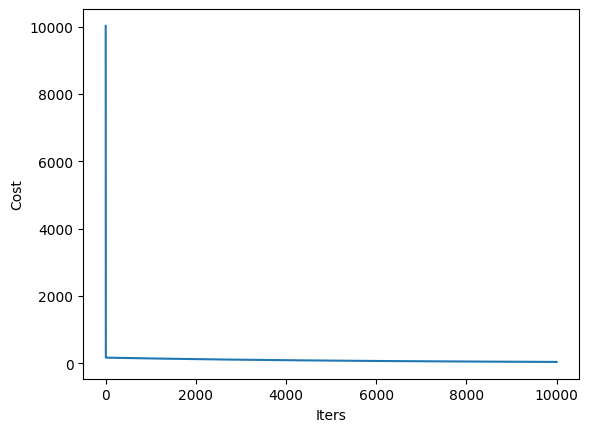

In [36]:
plt.plot(cost_history)
plt.xlabel("Iters")
plt.ylabel("Cost")
plt.show()

In [37]:
predictions = np.zeros(m)
for i in range(m):
  f_wb = np.dot(w_final ,x_train[i]) + b_final
  predictions[i] = f_wb
print(predictions)


[ 10.70585259  12.61685469  15.89121017  20.68249015  27.14426575
  35.43010808  45.69358828  58.08827745  72.76774672  89.88556721
 109.59531003 132.05054631 157.40484717 185.81178372 217.42492709
 252.39784839 290.88411876 333.03730929 379.01099112]


In [41]:
new_cost = compute_cost(x_train, y, w_final , b_final)
print(new_cost)

39.88883659649591


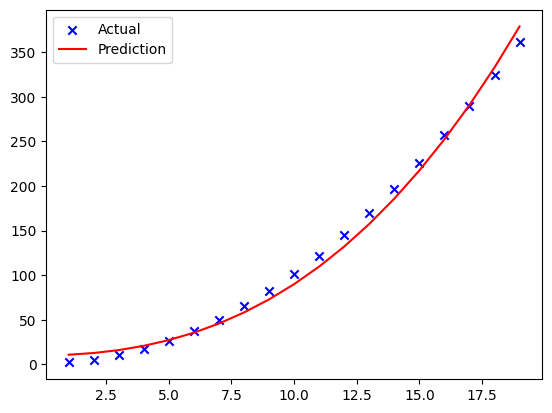

In [39]:
plt.scatter(x , y, label = "Actual" , marker = 'x' , c = 'b')
plt.plot(x , predictions , label = "Prediction" , c = 'r')
plt.legend()
plt.show()

In [40]:
print(y[10])
print(predictions[10])

print(y[15])
print(predictions[15])

122
109.5953100302166
257
252.39784839460833


In [42]:
x_features = np.array(['x1' , 'x2' , 'x3'])

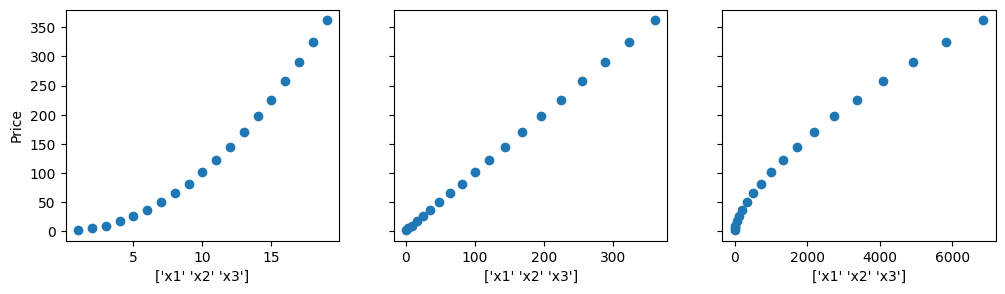

In [43]:
fig, ax = plt.subplots(1,3 , figsize=(12,3), sharey= True)
for i in range(len(ax)):
  ax[i].scatter(x_train[: , i], y)
  ax[i].set_xlabel(x_features)
ax[0].set_ylabel("Price")
plt.show()


In [44]:
def zscore_normalized(x):
  mu = np.mean(x , axis=0)
  sigma = np.std(x, axis = 0)
  x_mean = x- mu
  x_norm = (x - mu) / sigma

  return mu, sigma, x_norm


In [46]:
mu , sigma, x_norm = zscore_normalized(x_train)
print(mu)
print(sigma)
print(x_norm)

[  10.  130. 1900.]
[   5.47722558  112.75637454 2100.94978522]
[[-1.64316767 -1.14405949 -0.90387691]
 [-1.46059349 -1.11745345 -0.90054508]
 [-1.2780193  -1.07311006 -0.89150155]
 [-1.09544512 -1.01102931 -0.87389047]
 [-0.91287093 -0.93121121 -0.84485598]
 [-0.73029674 -0.83365575 -0.80154224]
 [-0.54772256 -0.71836293 -0.74109339]
 [-0.36514837 -0.58533276 -0.66065358]
 [-0.18257419 -0.43456523 -0.55736696]
 [ 0.         -0.26606035 -0.42837768]
 [ 0.18257419 -0.0798181  -0.27082989]
 [ 0.36514837  0.12416149 -0.08186773]
 [ 0.54772256  0.34587845  0.14136464]
 [ 0.73029674  0.58533276  0.40172307]
 [ 0.91287093  0.84252443  0.70206342]
 [ 1.09544512  1.11745345  1.04524155]
 [ 1.2780193   1.41011983  1.43411329]
 [ 1.46059349  1.72052357  1.8715345 ]
 [ 1.64316767  2.04866466  2.36036103]]


In [61]:
X = np.column_stack([x , x**2 , x**3])
print(X)
print(f"Peak to peak range by columns in raw dataset: {np.ptp(X, axis = 0)}")

print(f"Peak to peak range by columns in normalized dataset: {np.ptp(x_norm, axis = 0)}")

[[   1    1    1]
 [   2    4    8]
 [   3    9   27]
 [   4   16   64]
 [   5   25  125]
 [   6   36  216]
 [   7   49  343]
 [   8   64  512]
 [   9   81  729]
 [  10  100 1000]
 [  11  121 1331]
 [  12  144 1728]
 [  13  169 2197]
 [  14  196 2744]
 [  15  225 3375]
 [  16  256 4096]
 [  17  289 4913]
 [  18  324 5832]
 [  19  361 6859]]
Peak to peak range by columns in raw dataset: [  18  360 6858]
Peak to peak range by columns in normalized dataset: [3.28633535 3.19272415 3.26423794]


In [62]:
w_in = [0.1 ,0.2, 0.3]
b_in = 10
alpha = 0.1

In [63]:
cost, w_final , b_final = gradient_descent(x_norm, y, w_in, b_in, iters, alpha, compute_cost, compute_gradient)
print(cost)
print(w_final)
print(b_final)

Iteration: 0 , Cost: 9085.953971954385
Iteration: 1000 , Cost: 3.094930498863195
Iteration: 2000 , Cost: 2.58733480833937
Iteration: 3000 , Cost: 2.162989626214118
Iteration: 4000 , Cost: 1.8082407070126447
Iteration: 5000 , Cost: 1.511673664482885
Iteration: 6000 , Cost: 1.2637461699811023
Iteration: 7000 , Cost: 1.0564809189079896
Iteration: 8000 , Cost: 0.8832089532926998
Iteration: 9000 , Cost: 0.7383550816825788
[np.float64(9085.953971954385), np.float64(6388.592809183365), np.float64(4688.759356484396), np.float64(3554.9812008728463), np.float64(2758.4487886707007), np.float64(2174.311613532143), np.float64(1731.75539271082), np.float64(1388.61396169283), np.float64(1118.3475172772303), np.float64(903.2752787670134), np.float64(730.9885864139789), np.float64(592.3950883236578), np.float64(480.61045097833085), np.float64(390.2991709454201), np.float64(317.2601794380097), np.float64(258.15109787737026), np.float64(210.29491416726194), np.float64(171.53844086244735), np.float64(140.

In [64]:
predicts = np.zeros(m)
for i in range(m):
  f_wb = np.dot(w_final, x_norm[i]) + b_final
  predicts[i] = f_wb
print(predicts)

[ -0.43855797   4.07628706  10.16396719  17.87639597  27.26548695
  38.38315365  51.28130962  66.0118684   82.62674353 101.17784856
 121.71709701 144.29640243 168.96767836 195.78283834 224.7937959
 256.0524646  289.61075797 325.52058955 363.83387288]


In [75]:
mu, sigma, y_norm = zscore_normalized(y)
print(mu)
print(sigma)
print(y_norm)
print(type(y_norm))

131.0
112.75637454263949
[-1.14405949 -1.11745345 -1.07311006 -1.01102931 -0.93121121 -0.83365575
 -0.71836293 -0.58533276 -0.43456523 -0.26606035 -0.0798181   0.12416149
  0.34587845  0.58533276  0.84252443  1.11745345  1.41011983  1.72052357
  2.04866466]
<class 'numpy.ndarray'>


In [77]:
print(y[10])
print(predicts[10])

122
121.71709700597589


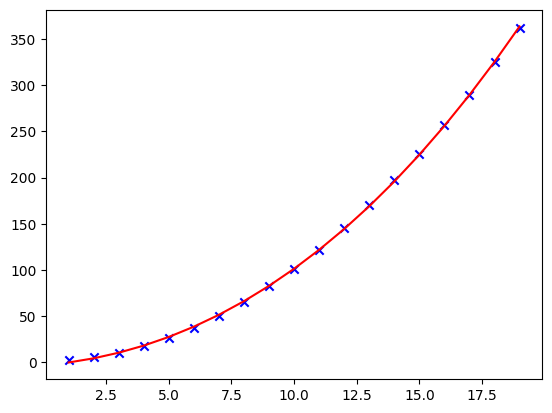

In [78]:
plt.scatter(x, y, label = 'Actual', marker = 'x', c='b')
plt.plot(x, predicts, label = "prediction" , c='r')
plt.show()

In [ ]:
x = np.arange(0,20,1)
y = np.cos(x/2)

X = np.c_[x, x**2, x**3,x**4, x**5, x**6, x**7, x**8, x**9, x**10, x**11, x**12, x**13]
X = zscore_normalize_features(X)

model_w,model_b = run_gradient_descent_feng(X, y, iterations=1000000, alpha = 1e-1)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Normalized x x**2, x**3 feature")
plt.plot(x,X@model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()


In [88]:
w = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
b= 10
iters = 10000
alpha = 0.2

In [90]:
x = np.arange(1, 20, 1)
print(x)
print(x.shape)
y = np.cos(x/2)
print(y)

X = np.column_stack([x , x **2 , x**3, x**4, x**4, x**5, x**6, x**7, x**8])
mu, sigma, X_norm = zscore_normalized(X)

cost_hist, w_fin , b_fin = gradient_descent(X_norm, y, w, b, iters, alpha, compute_cost, compute_gradient)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
(19,)
[ 0.87758256  0.54030231  0.0707372  -0.41614684 -0.80114362 -0.9899925
 -0.93645669 -0.65364362 -0.2107958   0.28366219  0.70866977  0.96017029
  0.97658763  0.75390225  0.34663532 -0.14550003 -0.6020119  -0.91113026
 -0.99717216]
Iteration: 0 , Cost: 38.05786792801259
Iteration: 1000 , Cost: 0.10193784280036607
Iteration: 2000 , Cost: 0.0709758368950107
Iteration: 3000 , Cost: 0.05062189517859875
Iteration: 4000 , Cost: 0.037237479729790246
Iteration: 5000 , Cost: 0.028432286712566743
Iteration: 6000 , Cost: 0.02263584608341909
Iteration: 7000 , Cost: 0.018816331950712983
Iteration: 8000 , Cost: 0.016295816409745874
Iteration: 9000 , Cost: 0.014628888307294396


In [91]:
predicts = np.zeros(m)
for i in range(m):
  f_wb = np.dot(w_fin, X_norm[i]) + b_fin
  predicts[i] = f_wb
print(predicts)

[ 1.06161738  0.35088564 -0.18774832 -0.55141434 -0.74326038 -0.77379016
 -0.6620521  -0.43646139 -0.13498701  0.19561422  0.50188528  0.7274962
  0.81927964  0.73599326  0.46037735  0.01512657 -0.51655561 -0.96510083
 -1.04264931]


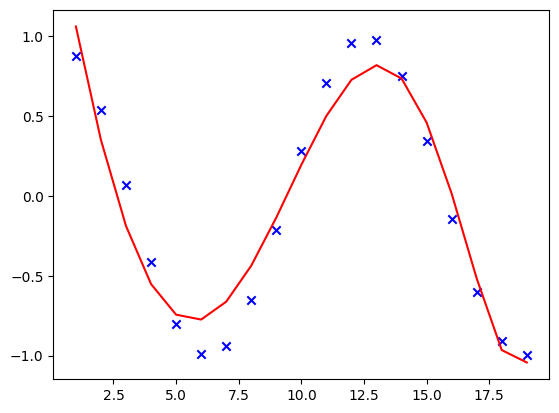

In [93]:
plt.scatter(x, y, marker = 'x' , c='b' , label="ACtal")
plt.plot(x, predicts, label = "Predicts" , c='r')
plt.show()